In [2]:
#Listing 1: CELL 1 – imports

import tensorflow as tf
from tensorflow . keras import layers , models
import matplotlib . pyplot as plt
import numpy as np
print ('tf version :', tf . __version__ )

tf version : 2.20.0


In [7]:
#Listing 2: CELL 2 – load MNIST (we start here as warm-up)

# Load the dataset that comes built into Keras
( x_tr, y_tr) , ( x_ts, y_ts ) = tf.keras.datasets.fashion_mnist.load_data ()

# Normalise pixel values from 0..255 to 0..1 ( helps training )
x_tr = x_tr.astype ('float32') / 255.0
x_ts = x_ts.astype ('float32') / 255.0
print ('train shape :', x_tr.shape ) # (60000 , 28 , 28)
print ('test shape :', x_ts.shape ) # (10000 , 28 , 28)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
train shape : (60000, 28, 28)
test shape : (10000, 28, 28)


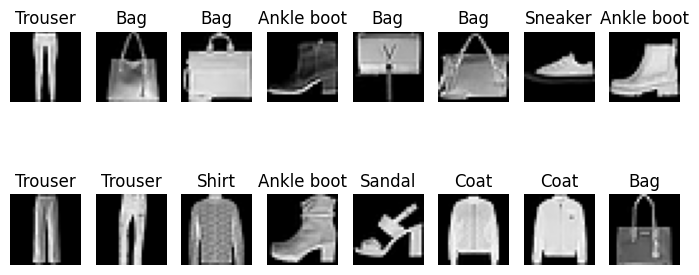

In [31]:
#Listing 3: CELL 3 – peek at 16 random images

fig , axes = plt . subplots (2 , 8 , figsize =(7,4) )
for ax in axes.flat :
  i = np.random.randint ( len( x_tr ) )
  ax.imshow ( x_tr [i] , cmap ='gray') # Added imshow and using 'gray' colormap
  ax.set_title ( class_names [ y_tr [i ]] ) # Using class names for title
  ax.axis ('off')
plt.tight_layout () ; plt . show ()

In [32]:
class_names = ['T- shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Then in your imshow loop , use: ax. set_title ( class_names [ y_train [i ]])

In [33]:
model = models.Sequential([
# Reshape adds a " channel " dimension : (28 , 28) -> (28 , 28 , 1)
layers.Reshape ((28 , 28 , 1) , input_shape =(28 , 28) ),

# Conv layer 1: 8 filters of size 3x3 + ReLU activation
layers.Conv2D (8 , 3 , activation ='relu', padding ='same'), layers.MaxPooling2D (2), # halve spatial size

# Conv layer 2: 16 filters
layers.Conv2D (16 , 3 , activation ='relu', padding ='same'), layers.MaxPooling2D (2),

layers . Conv2D (32 , 3 , activation ='relu', padding ='same') ,
layers . MaxPooling2D (2) ,

# Flatten 7 x7x16 = 784 numbers -> a single long vector
layers.Flatten (),
layers.Dense (32 , activation ='relu'),

# 10 output classes -> softmax gives 10 probabilities that sum to 1
layers.Dense (10 , activation ='softmax') ,
])

model.compile (optimizer ='adam',loss ='sparse_categorical_crossentropy',metrics =['accuracy'])
model.summary ()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,466 (60.41 KB)

 Trainable params: 15,466 (60.41 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
#Listing 5: CELL 5 – train for 5 epochs
history = model.fit (
x_tr , y_tr,
epochs =15,
validation_split =0.1,
batch_size =128,
verbose =2)

Epoch 1/15
422/422 - 36s - 85ms/step - accuracy: 0.9140 - loss: 0.2344 - val_accuracy: 0.9045 - val_loss: 0.2722
Epoch 2/15
422/422 - 30s - 71ms/step - accuracy: 0.9164 - loss: 0.2282 - val_accuracy: 0.9062 - val_loss: 0.2630
Epoch 3/15
422/422 - 26s - 63ms/step - accuracy: 0.9171 - loss: 0.2246 - val_accuracy: 0.9012 - val_loss: 0.2809
Epoch 4/15
422/422 - 26s - 61ms/step - accuracy: 0.9192 - loss: 0.2224 - val_accuracy: 0.8958 - val_loss: 0.2849
Epoch 5/15
422/422 - 24s - 57ms/step - accuracy: 0.9215 - loss: 0.2146 - val_accuracy: 0.9022 - val_loss: 0.2759
Epoch 6/15
422/422 - 25s - 60ms/step - accuracy: 0.9235 - loss: 0.2115 - val_accuracy: 0.9018 - val_loss: 0.2737
Epoch 7/15
422/422 - 26s - 60ms/step - accuracy: 0.9215 - loss: 0.2110 - val_accuracy: 0.9040 - val_loss: 0.2756
Epoch 8/15
422/422 - 25s - 60ms/step - accuracy: 0.9243 - loss: 0.2054 - val_accuracy: 0.9045 - val_loss: 0.2673
Epoch 9/15
422/422 - 26s - 61ms/step - accuracy: 0.9261 - loss: 0.2020 - val_accuracy: 0.9015 - 

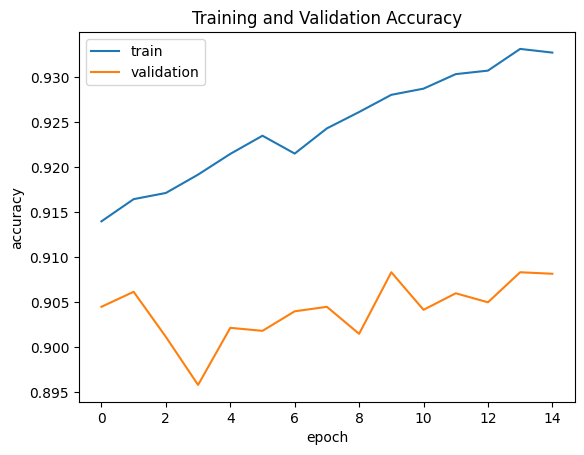

In [41]:
#Listing 6: CELL 6 – plot accuracy curves
plt.plot ( history.history ['accuracy'] , label ='train' )
plt.plot ( history.history ['val_accuracy'] , label ='validation' )
plt.xlabel ('epoch' ) ; plt.ylabel ('accuracy' ) ; plt.legend ()
plt.title ('Training and Validation Accuracy')
plt.show()

In [42]:
#Listing 7: CELL 7 – evaluate on the test set
test_loss , test_acc = model.evaluate ( x_ts, y_ts , verbose =0)
train_loss , train_acc = model.evaluate ( x_tr, y_tr , verbose =0)
print ( f'Test accuracy on fashion MNIST : { test_acc :.2%}')
print ( f'Train accuracy on fashion MNIST : { train_acc :.2%}')

Test accuracy on fashion MNIST : 90.71%
Train accuracy on fashion MNIST : 93.72%


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


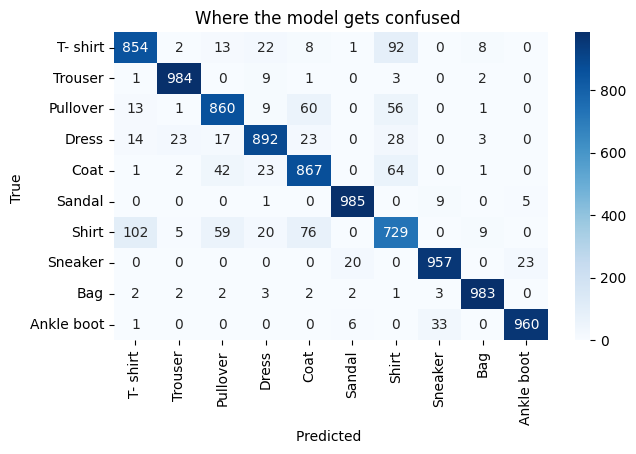

In [43]:
#Listing 8: CELL 8 – confusion matrix

from sklearn . metrics import confusion_matrix
import seaborn as sns

preds = model . predict ( x_ts ).argmax ( axis =1)
cm = confusion_matrix ( y_ts , preds )

plt.figure ( figsize =(7 , 4) )
sns.heatmap ( cm , annot = True , fmt ='d', cmap ='Blues',
xticklabels = class_names , yticklabels = class_names )
plt.xlabel ('Predicted ') ; plt . ylabel ('True ')
plt.title ('Where the model gets confused ') ; plt . show ()

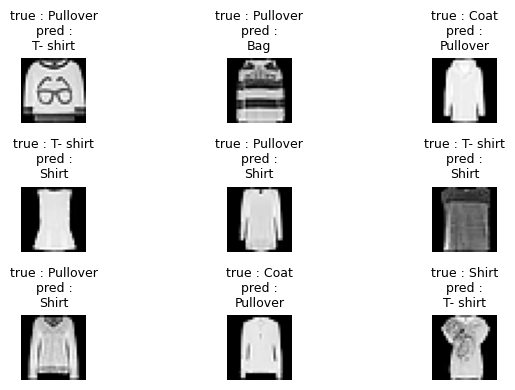

In [44]:
wrong = np . where ( preds != y_ts ) [0]
sample = np . random . choice ( wrong , 9 , replace = False )

fig , axes = plt . subplots (3 , 3 , figsize =(7, 4) )
for ax , i in zip( axes . flat , sample ) :
  ax . imshow ( x_ts [i] , cmap ='gray' )
  ax . set_title ( f'true : { class_names [ y_ts [i ]]}\npred :\n{ class_names [ preds [i]]}' ,
  fontsize =9)
  ax . axis ('off')
plt . tight_layout () ; plt.show ()

**A1**

Did the gap between train and test grow vs MNIST?
for MNIST dataset, the test accuracy was 98.33% while the train accuracy was 98.58%. This gives a generalization gap of 0.25% between training and test accuracy.

for the Fashion MNIST dataset, the training accuracy was 88.68%, the final validation accuracy was 88.58%, and the test accuracy was 88.05%. This gives a generalization gap of 0.63% between training and test accuracy.

Fashion MNIST is more complex than MNIST, making it generally more challenging for models to achieve the same level of accuracy and often leading to a slightly larger generalization gap compared to MNIST. The gap between mnist and fashion mnist grew about 0.38%.

---





**A2**

Did test accuracy go up or down? By how much?

The test accuracy went up from 89.17% to 89.42%. This is an increase of 0.25%.

---



**A3**

Around which epoch does validation accuracy stop improving?
the validation accuracy starts going down from epoch 7, but it does not continuously go down. there are multiple fluctuations after epoch 7. and the rate of improvement slows down and becomes less consistent.

Does train accuracy keep going up after that? What's that called?
yes, the train accuracy does keep increasing after that. this means the model is overfitting. it is learning the noise and specific pattens and is losing its ability to answer for unseen data.

---



**A4**

Look at the heatmap. Identify the 3 most-confused class pairs. (Look for non-diagonal cells with
the highest counts.) Submit them as (true_class, predicted_class, count).

(Shirt, T-shirt, 102)

(T-shirt, Shirt, 92)

(Shirt, Coat, 76)

---



**A5**

from cell 9:

image 1- yes. The image looks blurred and appears to be a sweater, and even a human would confuse it for a pullover.

image 2- yes. The model confused the handles of the bag to be armholes of a pullover.

image 9- yes. Because the image is blurred, the collar is not very visible and hence the ai predicted it was a t-shirt.

---



**A6**

1. Which two classes does your CNN confuse most?
*my model gets confused the most on two classes, ie, shirt with t-shirt and t-shirt with shirt.

2. Why do you think that’s happening (from the images, not the model)?
*In the images, some important qualities that distingish a shirt from a t-shirt, like the collar, buttons, etc, are not clearly visible as the images are very blurred.

3. If you had to fix this for production, what would you try? (More data? Bigger images? Colour
photos?)
*I would use bigger images with higher resolution to increase the image quality. Using colored images will also help to highlight the important distinguishing features of each clothing item.


---



In [9]:
#stretch (got some edits from google)
# CELL 10 - STRETCH TASK: Data Augmentation Model
stretch_model = models.Sequential([
    # 1. Augmentation layers go first
    layers . RandomFlip ('horizontal', input_shape=(28, 28, 1)),
    layers . RandomRotation (0.1) ,

    # Reshape adds a " channel " dimension : (28 , 28) -> (28 , 28 , 1)
    layers . Reshape ((28 , 28 , 1)) ,

    # Conv layer 1: 8 filters of size 3x3 + ReLU activation
    layers . Conv2D (8 , 3 , activation ='relu', padding ='same') ,
    layers . MaxPooling2D (2) , # halve spatial size

    # Conv layer 2: 16 filters
    layers . Conv2D (16 , 3 , activation ='relu', padding ='same') ,
    layers . MaxPooling2D (2) ,

    #Add a third Conv layer
    layers . Conv2D (32 , 3 , activation ='relu', padding ='same') ,
    layers . MaxPooling2D (2) ,

    # Flatten 7 x7x16 = 784 numbers -> a single long vector
    layers . Flatten () ,
    layers . Dense (32 , activation ='relu') ,

    # 10 output classes -> softmax gives 10 probabilities that sum to 1
    layers . Dense (10 , activation ='softmax') ,
])

# Compile the new stretch model
stretch_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the stretch model for 15 epochs
print("Training model with Data Augmentation...")
stretch_history = stretch_model.fit(
    x_tr, y_tr,
    epochs=15,
    validation_split=0.1,
    batch_size=128,
    verbose=2
)

# Evaluate the new stretch model on the test set
print("\nEvaluating Stretch Model:")
stretch_loss, stretch_acc = stretch_model.evaluate(x_ts, y_ts, verbose=0)
print(f"New Test Accuracy with Augmentation: {stretch_acc:.2%}")

Training model with Data Augmentation...
Epoch 1/15
422/422 - 31s - 73ms/step - accuracy: 0.6374 - loss: 0.9974 - val_accuracy: 0.7247 - val_loss: 0.6976
Epoch 2/15
422/422 - 27s - 64ms/step - accuracy: 0.7630 - loss: 0.6371 - val_accuracy: 0.7883 - val_loss: 0.5600
Epoch 3/15
422/422 - 27s - 64ms/step - accuracy: 0.7922 - loss: 0.5672 - val_accuracy: 0.7978 - val_loss: 0.5295
Epoch 4/15
422/422 - 43s - 102ms/step - accuracy: 0.8076 - loss: 0.5284 - val_accuracy: 0.8137 - val_loss: 0.5075
Epoch 5/15
422/422 - 27s - 65ms/step - accuracy: 0.8164 - loss: 0.5027 - val_accuracy: 0.8115 - val_loss: 0.4998
Epoch 6/15
422/422 - 27s - 64ms/step - accuracy: 0.8257 - loss: 0.4817 - val_accuracy: 0.8257 - val_loss: 0.4729
Epoch 7/15
422/422 - 27s - 64ms/step - accuracy: 0.8345 - loss: 0.4609 - val_accuracy: 0.8215 - val_loss: 0.4815
Epoch 8/15
422/422 - 41s - 97ms/step - accuracy: 0.8338 - loss: 0.4532 - val_accuracy: 0.8205 - val_loss: 0.4809
Epoch 9/15
422/422 - 27s - 65ms/step - accuracy: 0.840

**Stretch**

After augmentation, training accuracy is 85.68% and testing accuracy is 81.71%. The gap is 3.97%

before augmentation, training accuracy is 93.73% and testing accuracy is 90.71%. The gap is 3.02%.

Therefore, the gap betwwen training and testing data has reduced after augmentation.

Data augmentation helps because it prevents overfitting and forces your AI model to learn core concepts rather than memorising the exact training data.


---

